In [1]:
import numpy as np
import pandas as pd
idx = pd.IndexSlice
pd.options.display.max_columns = 500

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticks
import matplotlib.patheffects as pe
import seaborn as sb

In [1]:
from sklearn.decomposition import PCA
import umap
import hdbscan

In [3]:
def label_maker(group):
    
    mayor_str = ''
    for round in ['Mayor Round 1','Mayor Round 2','Mayor Round 3','Mayor Round 4']:
        max_share = race_by_cluster.loc[group,round].max()
        if max_share > .5:
            mayor_str += race_by_cluster.loc[group,round].idxmax().split(' ')[-1][0]

    council_str = ''
    council_vals = race_by_cluster.loc[group,'City of Boulder Council Candidates (Vote For=4)']
    council_vals_gt50 = council_vals[council_vals > .5]
    council_str += ''.join([name.split(' ')[-1][:4] for name in council_vals_gt50.sort_values(ascending=False).index])

    bvsd_a_str = ''
    bvsd_a_top = race_by_cluster.loc[group,'Boulder Valley School District RE-2 Director District A (4 Years) (Vote For=1)']
    if bvsd_a_top.max() > 0.5:
        bvsd_a_str += bvsd_a_top.idxmax().split(' ')[-1][0]

    ballot302_str = race_by_cluster.loc[group,'City of Boulder Ballot Question 302 (Vote For=1)'].idxmax().split('/')[0][0]

    ballot2A_str = race_by_cluster.loc[group,'City of Boulder Ballot Issue 2A (Vote For=1)'].idxmax().split('/')[0][0]

    return '{0}: {1}-{2}-{3}-{4}-{5}'.format(group,mayor_str,council_str,bvsd_a_str,ballot302_str,ballot2A_str)

## Load and clean data

In [5]:
#df = pd.read_excel("D:/Dropbox/Hacking/Boulder politics/Data/Statement of Votes/2023-CVR.xlsx",header=[0,1])
df = pd.read_excel("/Users/briankeegan/Dropbox/Hacking/Boulder politics/Data/Statement of Votes/2023-CVR.xlsx",header=[0,1])

df.head()

CvrNumber       TabulatorNum            BatchId           RecordId  \
  Unnamed: 0_level_1 Unnamed: 1_level_1 Unnamed: 2_level_1 Unnamed: 3_level_1   
0                  1              108.0                1.0              104.0   
1                  2              108.0                1.0              103.0   
2                  3              108.0                1.0               66.0   
3                  4              108.0                1.0               65.0   
4                  5              108.0                1.0               42.0   

         ImprintedId         BallotType  \
  Unnamed: 4_level_1 Unnamed: 5_level_1   
0          108-1-104              DS-01   
1          108-1-103              DS-01   
2           108-1-66              DS-01   
3           108-1-65              DS-01   
4           108-1-42              DS-01   

  City of Boulder Mayoral Candidates (Number of positions=1, Number of ranks=4)  \
                                                              Aaron Brockett(1)   
0                                                1.0                              
1                                                0.0                              
2                                                0.0                              
3                                                0.0                              
4                                                0.0                              

                                                                   \
  Nicole Speer(1) Bob Yates(1) Paul Tweedlie(1) Aaron Brockett(2)   
0             0.0          0.0              0.0               0.0   
1             0.0          1.0              0.0               0.0   
2             0.0          1.0              0.0               0.0   
3             0.0          1.0              0.0               0.0   
4             0.0          1.0              0.0               0.0   

                                                                   \
  Nicole Speer(2) Bob Yates(2) Paul Tweedlie(2) Aaron Brockett(3)   
0             1.0          0.0              0.0               0.0   
1             0.0          0.0              1.0               1.0   
2             0.0          0.0              1.0               0.0   
3             0.0          0.0              0.0               0.0   
4             0.0          0.0              0.0               0.0   

                                                                   \
  Nicole Speer(3) Bob Yates(3) Paul Tweedlie(3) Aaron Brockett(4)   
0             0.0          1.0              0.0               0.0   
1             0.0          0.0              0.0               0.0   
2             0.0          0.0              0.0               0.0   
3             0.0          0.0              0.0               0.0   
4             0.0          0.0              0.0               0.0   

                                                 \
  Nicole Speer(4) Bob Yates(4) Paul Tweedlie(4)   
0             0.0          0.0              1.0   
1             1.0          0.0              0.0   
2             0.0          0.0              0.0   
3             0.0          0.0              0.0   
4             0.0          0.0              0.0   

  City of Boulder Council Candidates (Vote For=4)               \
                                     Terri Brncic Jenny Robins   
0                                             0.0          0.0   
1                                             1.0          1.0   
2                                             1.0          1.0   
3                                             1.0          1.0   
4                                             0.0          1.0   

                                                                               \
  Aaron Gabriel Neyer Jacques Decalo Silas Atkins Waylon Lewis Ryan Schuchard   
0                 0.0            0.0          1.0          0.0            1.0   
1                 0.0            0.0       

In [6]:
id_multiindex_cols = pd.MultiIndex.from_tuples([('CVR','Number'),('Tabulator','Number'),('Batch','ID'),('Record','ID'),('Imprinted','ID'),('BallotType','ID')])
# df.iloc[:,:6].columns = id_multiindex_cols

rounds = ['Mayor Round {0}'.format(i) for i in range(1,5)]
candidates = ['Aaron Brockett','Nicole Speer','Bob Yates','Paul Tweedlie']
mayoral_multiindex_cols = pd.MultiIndex.from_product([rounds,candidates])
# df.iloc[:,6:22] = mayoral_multiindex_cols

df.columns = id_multiindex_cols.append([mayoral_multiindex_cols,df.columns[22:]])

df.head()

CVR Tabulator Batch Record  Imprinted BallotType  Mayor Round 1  \
  Number    Number    ID     ID         ID         ID Aaron Brockett   
0      1     108.0   1.0  104.0  108-1-104      DS-01            1.0   
1      2     108.0   1.0  103.0  108-1-103      DS-01            0.0   
2      3     108.0   1.0   66.0   108-1-66      DS-01            0.0   
3      4     108.0   1.0   65.0   108-1-65      DS-01            0.0   
4      5     108.0   1.0   42.0   108-1-42      DS-01            0.0   

                                        Mayor Round 2                         \
  Nicole Speer Bob Yates Paul Tweedlie Aaron Brockett Nicole Speer Bob Yates   
0          0.0       0.0           0.0            0.0          1.0       0.0   
1          0.0       1.0           0.0            0.0          0.0       0.0   
2          0.0       1.0           0.0            0.0          0.0       0.0   
3          0.0       1.0           0.0            0.0          0.0       0.0   
4          0.0       1.0           0.0            0.0          0.0       0.0   

                 Mayor Round 3                                       \
  Paul Tweedlie Aaron Brockett Nicole Speer Bob Yates Paul Tweedlie   
0           0.0            0.0          0.0       1.0           0.0   
1           1.0            1.0          0.0       0.0           0.0   
2           1.0            0.0          0.0       0.0           0.0   
3           0.0            0.0          0.0       0.0           0.0   
4           0.0            0.0          0.0       0.0           0.0   

   Mayor Round 4                                       \
  Aaron Brockett Nicole Speer Bob Yates Paul Tweedlie   
0            0.0          0.0       0.0           1.0   
1            0.0          1.0       0.0           0.0   
2            0.0          0.0       0.0           0.0   
3            0.0          0.0       0.0           0.0   
4            0.0          0.0       0.0           0.0   

  City of Boulder Council Candidates (Vote For=4)               \
                                     Terri Brncic Jenny Robins   
0                                             0.0          0.0   
1                                             1.0          1.0   
2                                             1.0          1.0   
3                                             1.0          1.0   
4                                             0.0          1.0   

                                                                               \
  Aaron Gabriel Neyer Jacques Decalo Silas Atkins Waylon Lewis Ryan Schuchard   
0                 0.0            0.0          1.0          0.0            1.0   
1                 0.0            0.0          0.0          0.0            0.0   
2                 0.0            0.0          0.0          0.0            0.0   
3                 0.0            0.0          0.0          0.0            0.0   
4                 0.0            0.0          0.0          0.0            0.0   

                                         \
  Tara Winer Tina Marquis Taishya Adams   
0        1.0          0.0           1.0   
1        1.0          1.0           0.0   
2        1.0          1.0           0.0   
3        1.0          0.0           1.0   
4        1.0          0.0           0.0   

  City of Lafayette City Council Candidates (Vote For=4)                       \
                                              Tim Barnes JD Mangat Eric Ryant   
0                                                NaN           NaN        NaN   
1                                                NaN           NaN        NaN   
2                                                NaN           NaN        NaN   
3                                                NaN           NaN        NaN   
4                                                NaN           NaN        NaN   

                                                               \
  John W. Watson Gala W. Orba David Fridland Crystal Gallegos   
0         

In [8]:
mayoral_multiindex_cols

MultiIndex([('Mayor Round 1', 'Aaron Brockett'),
            ('Mayor Round 1',   'Nicole Speer'),
            ('Mayor Round 1',      'Bob Yates'),
            ('Mayor Round 1',  'Paul Tweedlie'),
            ('Mayor Round 2', 'Aaron Brockett'),
            ('Mayor Round 2',   'Nicole Speer'),
            ('Mayor Round 2',      'Bob Yates'),
            ('Mayor Round 2',  'Paul Tweedlie'),
            ('Mayor Round 3', 'Aaron Brockett'),
            ('Mayor Round 3',   'Nicole Speer'),
            ('Mayor Round 3',      'Bob Yates'),
            ('Mayor Round 3',  'Paul Tweedlie'),
            ('Mayor Round 4', 'Aaron Brockett'),
            ('Mayor Round 4',   'Nicole Speer'),
            ('Mayor Round 4',      'Bob Yates'),
            ('Mayor Round 4',  'Paul Tweedlie')],
           )

Remove redacted rows.

In [10]:
df = df[~df[('CVR','Number')].isin(['RCV Redacted & Randomly Sorted','Redacted & Aggregated'])]

Filter to DS-01 ballot for City of Boulder.

In [11]:
# cob_df = df[df[('BallotType','Unnamed: 5_level_1')].isin(['DS-01','DS-16'])]
cob_df = df[df[('BallotType','ID')].isin(['DS-01'])]
cob_df = cob_df.dropna(axis=1,how='all')

cob_original_cols = cob_df.columns

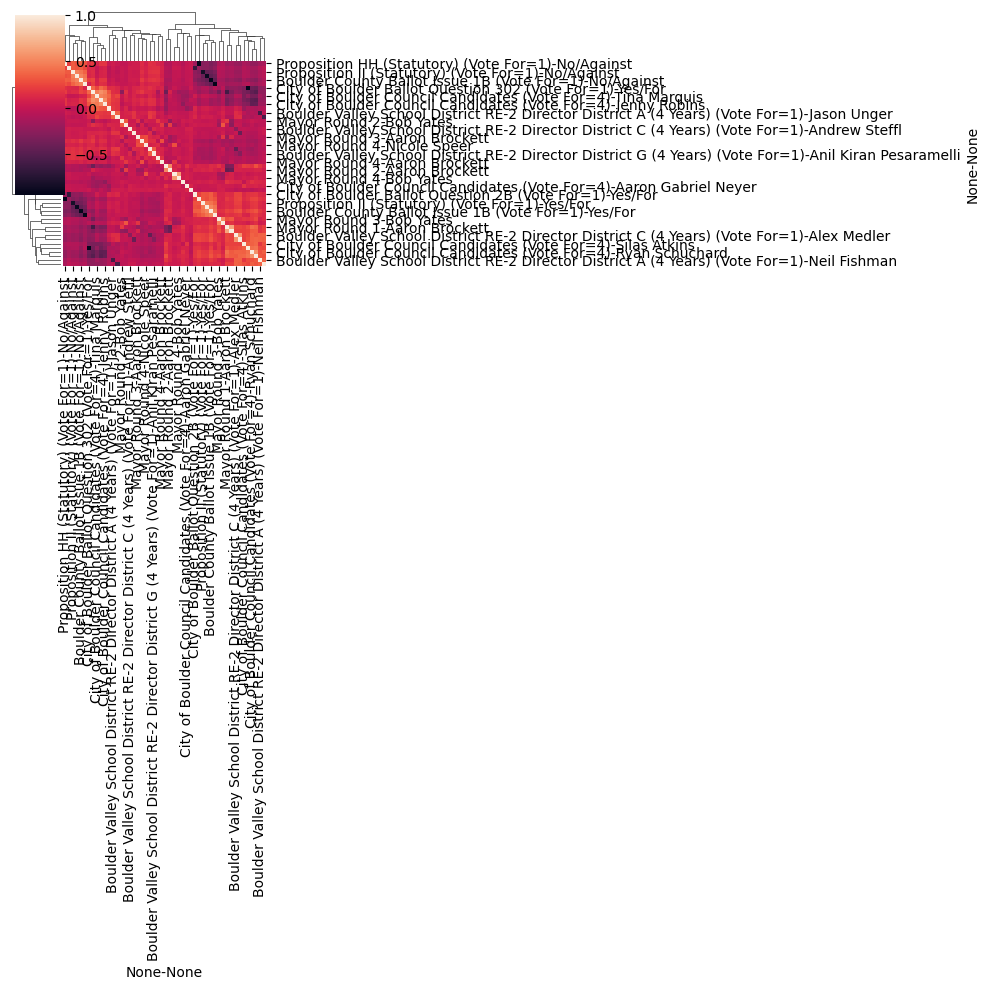

In [20]:
cols = cob_df.columns[6:]
sb.clustermap(cob_df.loc[:,cols].corr())

## Embedding

Training data.

In [65]:
X = cob_df.iloc[:,6:]
X.shape

(34082, 50)

In [ ]:
tsne = TSNE(

### UMAP

In [478]:
umap_reducer = umap.UMAP(
    n_neighbors = 30,
    min_dist = 0,
    # repulsion_strength = 2
)

umap_embedding = umap_reducer.fit_transform(X)

cob_df[[('UMAP',0),('UMAP',1)]] = umap_embedding

umap_embedding.shape

(34082, 2)

In [449]:
umap_clustering = umap.UMAP(n_neighbors = 30,min_dist = 0).fit_transform(X)

In [521]:
for i in range(5,250,10):
    _labels = hdbscan.HDBSCAN(min_samples=i,min_cluster_size=800,core_dist_n_jobs=-1).fit_predict(umap_embedding)
    print(i,len(set(_labels)),sum(_labels == -1))

5 18 2987
15 17 2382
25 14 907
35 14 926
45 16 2069
55 17 2123
65 16 2269
75 14 786
85 11 313
95 16 2469
105 11 319
115 11 306
125 11 325
135 11 315
145 11 325
155 11 314
165 11 49
175 11 337
185 11 316
195 11 321
205 11 328
215 11 333
225 11 340
235 11 347
245 10 1170


In [526]:
hdbscan_labels = hdbscan.HDBSCAN(min_samples=25,min_cluster_size=800,core_dist_n_jobs=-1).fit_predict(umap_embedding)

cob_df[('Cluster','Label')] = hdbscan_labels

print(len(set(hdbscan_labels)))

cluster_counts = cob_df[('Cluster','Label')].value_counts()

cluster_counts

14


(Cluster, Label)
 12    9426
 0     6028
 11    2613
 2     2170
 7     2140
 4     1850
 1     1659
 5     1624
 9     1390
 8     1215
 3     1129
 6     1092
-1      907
 10     839
Name: count, dtype: int64

In [527]:
gb = cob_df.groupby([('Cluster','Label')])

race_by_cluster = gb[cob_original_cols[6:]].sum().div(cob_df[('Cluster','Label')].value_counts().sort_index(),axis=0)
race_by_cluster.to_csv('races_by_cluster.csv')

race_by_cluster.loc[0:].style.background_gradient(axis=1,cmap='coolwarm').set_sticky(0)

In [528]:
cluster_desc = {}

for group in race_by_cluster.loc[0:].index:
    cluster_desc[group] = label_maker(group)

cluster_desc

{0: '0: SB-AdamSchu-F-N-Y',
 1: '1: ---Y-Y',
 2: '2: BS-AdamSchu-F-N-Y',
 3: '3: BSY-SchuAdamWineAtki-U-N-Y',
 4: '4: BS-SchuAdamWine-F-Y-Y',
 5: '5: Y-WineBrncMarqRobi--Y-Y',
 6: '6: YSBT-WineBrncMarq-U-Y-Y',
 7: '7: BYS-WineSchu-U-Y-Y',
 8: '8: BS-SchuAdamWine--N-Y',
 9: '9: BSY-WineAdamSchu-U-Y-Y',
 10: '10: BS-AdamSchuWine-U-N-Y',
 11: '11: Y-BrncWineRobi--Y-N',
 12: '12: Y-WineBrncMarqRobi-U-Y-Y'}

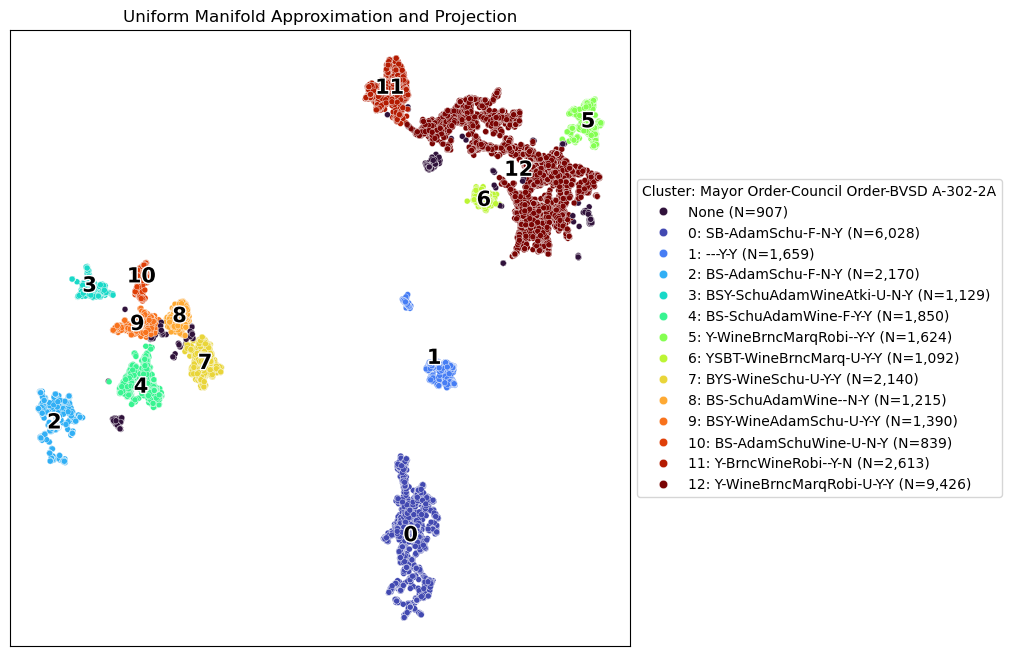

In [529]:
f,ax = plt.subplots(figsize=(8,8))

sb.scatterplot(
    data = cob_df,
    x = ('UMAP',0),
    y = ('UMAP',1),
    size = 50,
    # alpha = .25,
    hue = ('Cluster','Label'),
    palette = 'turbo',
    legend = 'full',
    linewidth = .25,
    ax = ax
)

for cluster in cob_df[('Cluster','Label')].unique():
    if cluster > -1:
        _df = cob_df[cob_df[('Cluster','Label')] == cluster]
        _x_mean = _df[('UMAP',0)].mean()
        _y_mean = _df[('UMAP',1)].mean()
        ax.annotate(
            text = cluster,
            xy = (_x_mean,_y_mean),
            fontsize=15,
            ha='center',
            va='center',
            weight='bold',
            path_effects=[pe.withStroke(linewidth=2,foreground='w')]
        )

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[:-1], 
    labels = ["{0} (N={1:,})".format(cluster_desc.get(int(i)),cluster_counts.loc[int(i)]) for i in labels[:-1]], 
    title = 'Cluster: Mayor Order-Council Order-BVSD A-302-2A',
    loc='center left',
    bbox_to_anchor=(1,.5)
)

ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_title('Uniform Manifold Approximation and Projection')

# f.tight_layout(bbox_inches='tight')
f.savefig('umap_embedding.png',bbox_inches='tight')

### PCA

In [439]:
pca = PCA(n_components=2,random_state=42)

pca_embedding = pca.fit_transform(X)

cob_df[[('PCA',0),('PCA',1)]] = pca_embedding

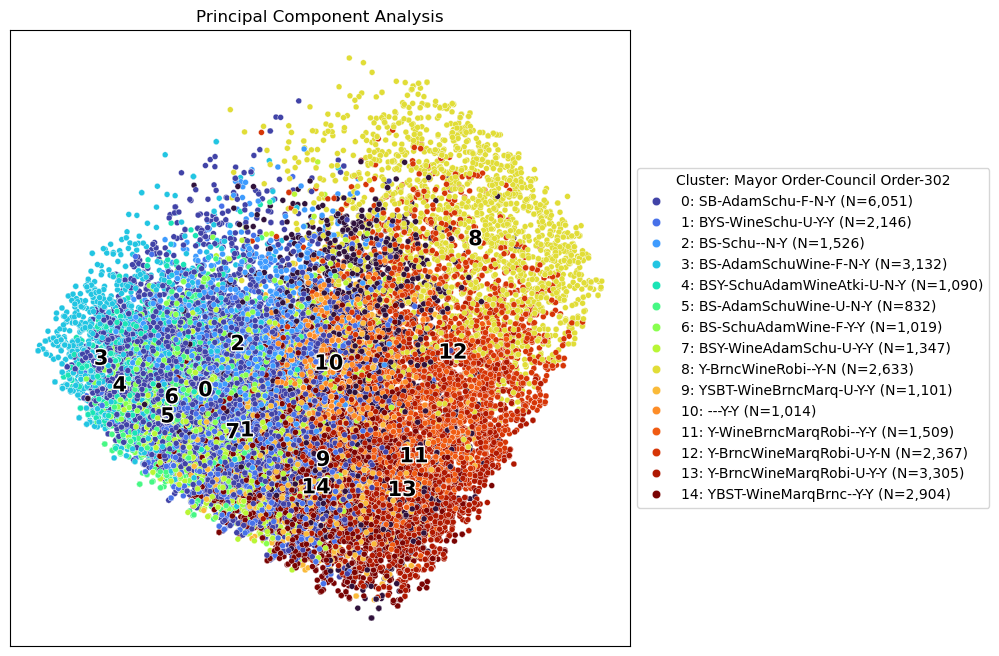

In [440]:
f,ax = plt.subplots(figsize=(8,8))

sb.scatterplot(
    data = cob_df,
    x = ('PCA',0),
    y = ('PCA',1),
    size = 50,
    # alpha = .25,
    hue = ('Cluster','Label'),
    palette = 'turbo',
    legend = 'full',
    linewidth = .25,
    ax = ax
)

for cluster in cob_df[('Cluster','Label')].unique():
    if cluster >= 0:
        _df = cob_df[cob_df[('Cluster','Label')] == cluster]
        _x_mean = _df[('PCA',0)].mean()
        _y_mean = _df[('PCA',1)].mean()
        ax.annotate(
            text = cluster,
            xy = (_x_mean,_y_mean),
            fontsize=15,
            ha='center',
            va='center',
            weight='bold',
            path_effects=[pe.withStroke(linewidth=2,foreground='w')]
        )

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[1:-1], 
    labels = ["{0} (N={1:,})".format(cluster_desc.get(int(i)),cluster_counts.loc[int(i)]) for i in labels[1:-1]], 
    title = 'Cluster: Mayor Order-Council Order-302',
    loc='center left',
    bbox_to_anchor=(1,.5)
)

ax.set_title('Principal Component Analysis')
ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)
ax.set_xlabel(None)
ax.set_ylabel(None)

# f.tight_layout(bbox_inches='tight')
f.savefig('pca_embedding.png',bbox_inches='tight')